In [1]:
!pip install qiskit==1.4.3
!pip install qiskit_nature==0.7.2
!pip install qiskit_aer==0.17.1
!pip install pyscf
!pip install rdkit

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem

def cap_structure(input_pdb, output_pdb):
    """
    Reads a PDB file, identifies and caps dangling bonds with hydrogen atoms,
    and saves the capped structure to a new PDB file.
    """
    # Read the molecule from the PDB file, sanitizing it to fix valency issues
    mol = Chem.MolFromPDBFile(input_pdb, sanitize=True, removeHs=False)

    if mol is None:
        print(f"Error: Could not read molecule from {input_pdb}")
        return

    # Add hydrogens to all atoms to ensure full valency
    mol = Chem.AddHs(mol, explicitOnly=True)

    # Save the new molecule with the added hydrogens
    writer = Chem.PDBWriter(output_pdb)
    writer.write(mol)
    writer.close()

    print(f"Structure from '{input_pdb}' has been capped and saved to '{output_pdb}'")

if __name__ == "__main__":
    input_filea = "set3mut17-21.pdb"
    output_filea = "res_17_21_cappeda.pdb"
    cap_structure(input_filea, output_filea)
    input_filew = "set3wt17-21.pdb"
    output_filew = "res_17_21_cappedw.pdb"
    cap_structure(input_filew, output_filew)

Structure from 'set3mut17-21.pdb' has been capped and saved to 'res_17_21_cappeda.pdb'
Structure from 'set3wt17-21.pdb' has been capped and saved to 'res_17_21_cappedw.pdb'


In [3]:
def convert_pdb_to_xyz(input_pdb, output_xyz):
    """
    Converts a PDB file to an XYZ file using RDKit.
    """
    # Read the molecule from the PDB file
    mol = Chem.MolFromPDBFile(input_pdb, sanitize=False, removeHs=False)

    if mol is None:
        print(f"Error: Could not read molecule from {input_pdb}")
        return

    # Create an XYZ file writer
    writer = Chem.PDBWriter(output_xyz)
    writer.write(mol)
    writer.close()

    # RDKit's PDBWriter can be tricky with the output format.
    # A more robust approach for XYZ is to build it manually:

    with open(output_xyz, 'w') as f:
        # Write the number of atoms
        f.write(f"{mol.GetNumAtoms()}\n\n")
        # Write each atom's symbol and coordinates
        for atom in mol.GetAtoms():
            pos = mol.GetConformer().GetAtomPosition(atom.GetIdx())
            symbol = atom.GetSymbol()
            f.write(f"{symbol}\t{pos.x:.4f}\t{pos.y:.4f}\t{pos.z:.4f}\n")

    print(f"Successfully converted '{input_pdb}' to '{output_xyz}'")

if __name__ == "__main__":
    # Replace these filenames with your actual file names
    input_filea = "res_17_21_cappeda.pdb"
    output_filea = "res_17_21_cappeda.xyz"
    convert_pdb_to_xyz(input_filea, output_filea)
    input_filew = "res_17_21_cappedw.pdb"
    output_filew = "res_17_21_cappedw.xyz"
    convert_pdb_to_xyz(input_filew, output_filew)

Successfully converted 'res_17_21_cappeda.pdb' to 'res_17_21_cappeda.xyz'
Successfully converted 'res_17_21_cappedw.pdb' to 'res_17_21_cappedw.xyz'


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver, VQE
from qiskit_algorithms.optimizers import COBYLA, L_BFGS_B, SPSA, SLSQP
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo as Molecule
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.units import DistanceUnit
from qiskit.circuit.library import TwoLocal
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.drivers import PySCFDriver, MethodType
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit.circuit.library import EfficientSU2
from qiskit_aer import AerSimulator, Aer
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import EstimatorV2, Estimator
import qiskit_nature.settings
from pyscf import solvent, gto, scf
from pyscf.solvent import ddCOSMO

qiskit_nature.settings.use_pauli_sum_op = False

In [5]:
import qiskit.utils
import qiskit_nature.utils
import qiskit_aer.utils

print(f"qiskit version: {qiskit.__version__}")
print(f"qiskit-nature version: {qiskit_nature.__version__}")
print(f"qiskit-aer version: {qiskit_aer.__version__}")

qiskit version: 1.4.3
qiskit-nature version: 0.7.2
qiskit-aer version: 0.17.1


In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver, MethodType
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import ParityMapper, JordanWignerMapper
from qiskit_nature.second_q.problems import ElectronicStructureProblem
from pyscf import gto, scf, solvent
from pyscf.tools import cubegen

def log_orbital_energies(name, orbital_energies, orbital_occupations, log_list, orbitals=[2,3,4,5]):
    for i in orbitals:
        log_list.append({
            "fragment": name,
            "orbital_index": i,
            "energy": orbital_energies[i],
            "occupation": orbital_occupations[i]
        })
    print(log_list)
    return log_list

def create_abeta_driver(atom_string, charge, spin, name, basis='sto-3g'):
    """
    Creates and returns a Qiskit-compatible ElectronicStructureProblem.
    Solvent effects (ddCOSMO) are applied manually in PySCF but not captured in Qiskit integrals.
    """
    # Manual PySCF run with ddCOSMO (for reference or logging)
    mol = gto.Mole()
    mol.atom = atom_string
    mol.unit = 'Angstrom'
    mol.basis = basis
    mol.charge = charge
    mol.spin = spin
    mol.build()

    mf = scf.RHF(mol).ddCOSMO()
    mf.with_solvent.eps = 80.0
    mf.kernel(level_shift=0.2)
    print("Total RHF energy:", mf.e_tot, "Hartree")
    mo_coeff1 = mf.mo_coeff.copy()
    mo_occ1 = mf.mo_occ.copy()
    
    orbital1s = [150, 151, 152, 153]
    for i in orbital1s:
        cubegen.orbital(mol, f'orbital{i}_{name}.cube', mo_coeff1[:,i])


    driver = PySCFDriver(
        atom=atom_string,
        unit=DistanceUnit.ANGSTROM,
        basis=basis,
        charge=charge,
        spin=spin,
        method=MethodType.RHF
    )
    problem = driver.run()

    return problem

def get_homo_lumo_orbitals(problem, window=2):
    occ = problem.orbital_occupations
    homo_index = max(i for i, occ_val in enumerate(occ) if occ_val > 0)
    lumo_index = homo_index + 1
    return list(range(homo_index - window + 1, lumo_index + window))

def get_qubit_op(xyz_file_content, name):
    # Parse XYZ content
    lines = xyz_file_content.strip().split('\n')
    atom_data_string = '\n'.join(lines[2:]) if len(lines) > 2 else xyz_file_content.strip()

    current_charge = 0
    current_spin = 1


    problem = create_abeta_driver(atom_data_string, current_charge, current_spin, name)
    problem = create_abeta_driver(atom_data_string, current_charge, current_spin, name)

    for i, (occ, e) in enumerate(zip(problem.orbital_occupations, problem.orbital_energies)):
        print(f"[{name}] Orbital {i}: occ={occ:.2f}, energy={e:.6f} Hartree")

    orbital_log = []

    log_orbital_energies(name, problem.orbital_energies, problem.orbital_occupations, orbital_log)


    print(f"[{name}] Initial num_particles: {problem.num_particles}")
    print(f"[{name}] Initial num_spatial_orbitals: {problem.num_spatial_orbitals}")
    ansatz = TwoLocal(rotation_blocks='ry', entanglement_blocks='cz', reps=1)
    vqe_solver = VQE(EstimatorV2(), ansatz, SLSQP())
    solver = GroundStateEigensolver(JordanWignerMapper(), vqe_solver)
    # Step 2: Determine active orbitals
    if name == "wt":
       # Step 2: Determine active orbitals
        #temp_transformer = ActiveSpaceTransformer(num_electrons=4, num_spatial_orbitals=4, active_orbitals=list(range(4)))
        #temp_problem = temp_transformer.transform(problem)
        #temp_result = solver.solve(temp_problem)
        #active_orbitals = get_homo_lumo_orbitals(temp_problem, window=2)

        active_orbitals = [150, 151, 152, 153] #wt hardcoded
    else:
       # Step 2: Determine active orbitals
        #temp_transformer = ActiveSpaceTransformer(num_electrons=4, num_spatial_orbitals=4, active_orbitals=list(range(4)))
        #temp_problem = temp_transformer.transform(problem)
        #temp_result = solver.solve(temp_problem)
        #active_orbitals = get_homo_lumo_orbitals(temp_problem, window=2)
       active_orbitals = [150, 151, 152, 153]  # Arctic mutant hardcoded

    print(f"[{name}] Active orbitals selected: {active_orbitals}")

    # Step 3: Apply final transformer
    transformer = ActiveSpaceTransformer(
        num_electrons=4,
        num_spatial_orbitals=4,
        active_orbitals=active_orbitals
    )
    problem = transformer.transform(problem)

    # Step 4: Map to qubit Hamiltonian
    num_particles = problem.num_particles
    num_spatial_orbitals_transformed = problem.num_spatial_orbitals
    print(f"[{name}] Transformed num_particles: {num_particles}")
    print(f"[{name}] Transformed num_spatial_orbitals: {num_spatial_orbitals_transformed}")

    mapper = JordanWignerMapper()
    hamiltonian = mapper.map(problem.second_q_ops()[0])
    print(f"[{name}] Hamiltonian qubits: {hamiltonian.num_qubits}")

    return hamiltonian, num_particles, num_spatial_orbitals_transformed, problem, mapper


In [7]:
def read_xyz_file(filepath, charge, mult):
    with open(filepath, 'r') as f:
        lines = f.readlines()[2:]  # Skip atom count and comment
    mol_lines = [f"{charge} {mult}"]
    for line in lines:
        parts = line.split()
        if len(parts) < 4:
            continue
        atom = parts[0]
        x, y, z = map(float, parts[1:4])
        mol_lines.append(f"{atom} {x:.6f} {y:.6f} {z:.6f}")
    return "\n".join(mol_lines)

wt_xyz_content = read_xyz_file("res_17_21_cappedw.xyz", 0, 1)
arctic_xyz_content = read_xyz_file("res_17_21_cappeda.xyz", 0, 1)
print(wt_xyz_content)
print(f"Arctic: {arctic_xyz_content}")

0 1
N 43.270000 24.630000 54.790000
H 43.140000 24.720000 55.790000
C 42.160000 24.760000 53.880000
H 42.190000 23.920000 53.190000
C 40.830000 24.510000 54.590000
H 40.750000 25.210000 55.410000
H 40.810000 23.540000 55.090000
C 39.620000 24.380000 53.660000
H 39.590000 25.300000 53.070000
C 39.660000 23.210000 52.690000
H 40.430000 23.390000 51.930000
H 40.000000 22.300000 53.190000
H 38.690000 23.060000 52.230000
C 38.340000 24.310000 54.490000
H 38.210000 23.310000 54.880000
H 38.340000 25.070000 55.270000
H 37.510000 24.450000 53.800000
C 42.120000 26.100000 53.160000
O 41.750000 26.230000 51.990000
N 42.700000 27.110000 53.810000
H 42.930000 27.010000 54.790000
C 43.000000 28.400000 53.230000
H 42.040000 28.910000 53.190000
C 43.940000 29.170000 54.150000
H 43.390000 29.180000 55.100000
C 45.250000 28.450000 54.450000
H 45.590000 28.840000 55.410000
H 45.120000 27.390000 54.680000
H 45.910000 28.490000 53.590000
C 44.170000 30.590000 53.650000
H 44.620000 31.210000 54.420000
H 44

converged SCF energy = -1805.75944153685
Total RHF energy: -1805.7594415368521 Hartree
converged SCF energy = -1805.75944153685
Total RHF energy: -1805.7594415368485 Hartree
[wt] Orbital 0: occ=1.00, energy=-20.282233 Hartree
[wt] Orbital 1: occ=1.00, energy=-20.235816 Hartree
[wt] Orbital 2: occ=1.00, energy=-20.214267 Hartree
[wt] Orbital 3: occ=1.00, energy=-20.202916 Hartree
[wt] Orbital 4: occ=1.00, energy=-20.176813 Hartree
[wt] Orbital 5: occ=1.00, energy=-15.383356 Hartree
[wt] Orbital 6: occ=1.00, energy=-15.365051 Hartree
[wt] Orbital 7: occ=1.00, energy=-15.341126 Hartree
[wt] Orbital 8: occ=1.00, energy=-15.333057 Hartree
[wt] Orbital 9: occ=1.00, energy=-11.185376 Hartree
[wt] Orbital 10: occ=1.00, energy=-11.158878 Hartree
[wt] Orbital 11: occ=1.00, energy=-11.141392 Hartree
[wt] Orbital 12: occ=1.00, energy=-11.123738 Hartree
[wt] Orbital 13: occ=1.00, energy=-11.118037 Hartree
[wt] Orbital 14: occ=1.00, energy=-11.105882 Hartree
[wt] Orbital 15: occ=1.00, energy=-11.102

/tmp/ipykernel_4774/715170204.py:52: DeprecationWarning: Estimator has been deprecated as of Aer 0.15, please use EstimatorV2 instead.
  wt_data = run_vqe_with_plot(wt_hamiltonian, wt_problem, wt_mapper, wt_particles, wt_orbitals, label="WT")
/tmp/ipykernel_4774/715170204.py:52: DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.
  wt_data = run_vqe_with_plot(wt_hamiltonian, wt_problem, wt_mapper, wt_particles, wt_orbitals, label="WT")


WT - Iteration: 1, Energy: -0.5030520619106709
WT - Iteration: 2, Energy: -0.5095053556152421
WT - Iteration: 3, Energy: -0.5126359683707651
WT - Iteration: 4, Energy: -0.5341628920694439
WT - Iteration: 5, Energy: -0.5131583668320012
WT - Iteration: 6, Energy: -0.5321387284941701
WT - Iteration: 7, Energy: -0.5222172527683817
WT - Iteration: 8, Energy: -0.49558906794235774
WT - Iteration: 9, Energy: -0.5147081681854303
WT - Iteration: 10, Energy: -0.5114964154967474
WT - Iteration: 11, Energy: -0.5063050167583178
WT - Iteration: 12, Energy: -0.492025593488647
WT - Iteration: 13, Energy: -0.5167994837398572
WT - Iteration: 14, Energy: -0.5154716362777695
WT - Iteration: 15, Energy: -0.519332731636509
WT - Iteration: 16, Energy: -0.5446319972037257
WT - Iteration: 17, Energy: -0.5324801957458013
WT - Iteration: 18, Energy: -0.5162917642705822
WT - Iteration: 19, Energy: -0.532213957011049
WT - Iteration: 20, Energy: -0.5098208744091753
WT - Iteration: 21, Energy: -0.5302518846635149
WT 

/tmp/ipykernel_4774/715170204.py:53: DeprecationWarning: Estimator has been deprecated as of Aer 0.15, please use EstimatorV2 instead.
  arctic_data = run_vqe_with_plot(arctic_hamiltonian, arctic_problem, arctic_mapper, arctic_particles, arctic_orbitals, label="Arctic")
/tmp/ipykernel_4774/715170204.py:53: DeprecationWarning: Option approximation=False is deprecated as of qiskit-aer 0.13. It will be removed no earlier than 3 months after the release date. Instead, use BackendEstimator from qiskit.primitives.
  arctic_data = run_vqe_with_plot(arctic_hamiltonian, arctic_problem, arctic_mapper, arctic_particles, arctic_orbitals, label="Arctic")


Arctic - Iteration: 1, Energy: -0.7743085466182459
Arctic - Iteration: 2, Energy: -0.775481832452851
Arctic - Iteration: 3, Energy: -0.7949108108937287
Arctic - Iteration: 4, Energy: -0.7892262117174548
Arctic - Iteration: 5, Energy: -0.7986267801351755
Arctic - Iteration: 6, Energy: -0.7650686152907575
Arctic - Iteration: 7, Energy: -0.791724457714708
Arctic - Iteration: 8, Energy: -0.7642695199094443
Arctic - Iteration: 9, Energy: -0.7765502315907682
Arctic - Iteration: 10, Energy: -0.7532561043606136
Arctic - Iteration: 11, Energy: -0.7751178542276345
Arctic - Iteration: 12, Energy: -0.7570806183444676
Arctic - Iteration: 13, Energy: -0.7676834971427429
Arctic - Iteration: 14, Energy: -0.7754202163163012
Arctic - Iteration: 15, Energy: -0.7968547369341953
Arctic - Iteration: 16, Energy: -0.766645006210329
Arctic - Iteration: 17, Energy: -0.7770138849949242
Arctic - Iteration: 18, Energy: -0.7621298339112929
Arctic - Iteration: 19, Energy: -0.7543184787104582
Arctic - Iteration: 20, 

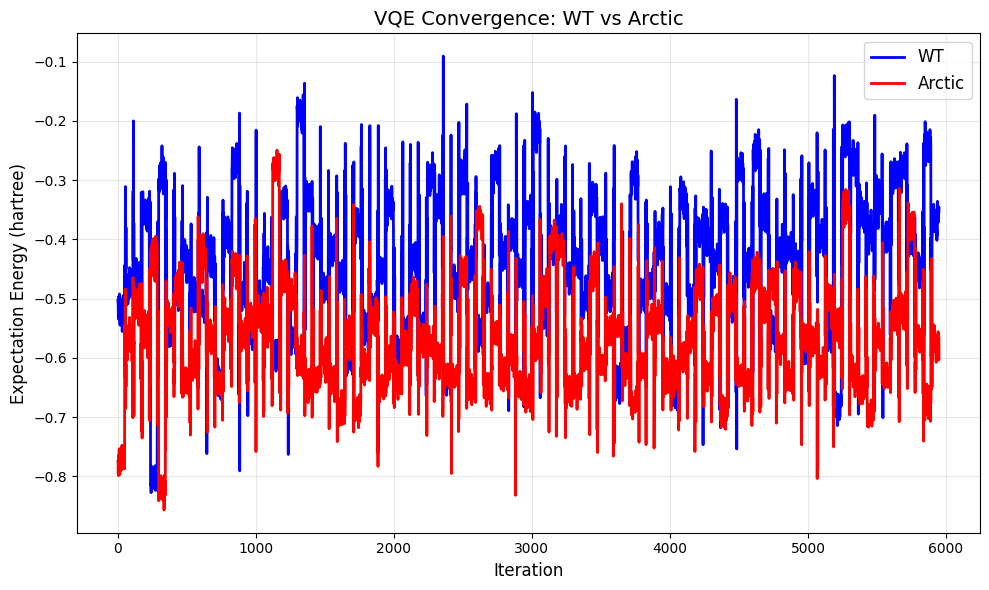


Final Energies:
WT:     -1804.757942337893 hartree
Arctic: -1804.9702423879771 hartree
ΔE:     -0.2123000500841954 hartree


In [ ]:
# Load XYZ files and get Hamiltonians (your existing code)
wt_hamiltonian, wt_particles, wt_orbitals, wt_problem, wt_mapper = get_qubit_op(wt_xyz_content, name="wt")
arctic_hamiltonian, arctic_particles, arctic_orbitals, arctic_problem, arctic_mapper = get_qubit_op(arctic_xyz_content, name="mut")

def run_vqe_with_plot(hamiltonian, problem, mapper, num_particles, num_orbitals, label=""):
    # Initialize lists to store convergence data
    energy_values = []
    iteration_counts = []
    
    # Callback function to track convergence
    def callback(eval_count, parameters, mean, std):
        energy_values.append(mean)
        iteration_counts.append(eval_count)
        print(f"{label} - Iteration: {eval_count}, Energy: {mean}")
    
    # Set up ansatz 
    num_qubits = hamiltonian.num_qubits
    init_state = HartreeFock(num_orbitals, num_particles, mapper)
    ansatz_body = TwoLocal(
        num_qubits=num_qubits,
        rotation_blocks=['ry', 'rz'],
        entanglement_blocks='cx',
        entanglement='linear',
        reps=2,
        insert_barriers=True,
    )
    ansatz = QuantumCircuit(num_qubits)
    ansatz.append(init_state, list(range(num_qubits)))
    ansatz.append(ansatz_body, list(range(num_qubits)))
    ansatz.draw(output='text', fold=80, plot_barriers=False, reverse_bits=True)
    print(ansatz.draw())
    
    # Run VQE with callback
    vqe = VQE(
        estimator=Estimator(),
        ansatz=ansatz,
        optimizer=SLSQP(maxiter=100),
        callback=callback
    )
    result = vqe.compute_minimum_eigenvalue(hamiltonian)
    interpreted_result = problem.interpret(result)
    
    # Return both the result and convergence data
    return {
        'result': interpreted_result,
        'energies': energy_values,
        'iterations': iteration_counts,
        'final_energy': interpreted_result.total_energies[0]
    }

# Run VQE for both systems
wt_data = run_vqe_with_plot(wt_hamiltonian, wt_problem, wt_mapper, wt_particles, wt_orbitals, label="WT")
arctic_data = run_vqe_with_plot(arctic_hamiltonian, arctic_problem, arctic_mapper, arctic_particles, arctic_orbitals, label="Arctic")

# Create convergence plot
plt.figure(figsize=(10, 6))
plt.plot(wt_data['iterations'], wt_data['energies'], 'b-', label='WT', linewidth=2)
plt.plot(arctic_data['iterations'], arctic_data['energies'], 'r-', label='Arctic', linewidth=2)

# Add horizontal lines for final energies
#plt.axhline(y=wt_data['final_energy'], color='b', linestyle='--', alpha=0.5)
#plt.axhline(y=arctic_data['final_energy'], color='r', linestyle='--', alpha=0.5)

# Format plot
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Expectation Energy (hartree)', fontsize=12)
plt.title('VQE Convergence: WT vs Arctic', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show or save plot
plt.savefig('vqe_convergence_comparison1.png', dpi=300)
plt.show()

# Compare final energies
print(f"\nFinal Energies:")
print(f"WT:     {wt_data['final_energy']} hartree")
print(f"Arctic: {arctic_data['final_energy']} hartree")
print(f"ΔE:     {arctic_data['final_energy'] - wt_data['final_energy']} hartree")

In [11]:
import mdtraj as md

traj1 = md.load_pdb("res_17_21_cappedw.pdb")
traj2 = md.load_pdb("res_17_21_cappeda.pdb")

backbone_atoms = ['N', 'CA', 'C']
backbone_indices = [atom.index for atom in traj1.topology.atoms if atom.name in backbone_atoms]

rms = md.rmsd(traj2, traj1, atom_indices=backbone_indices)
print(rms)

[0.24473402]


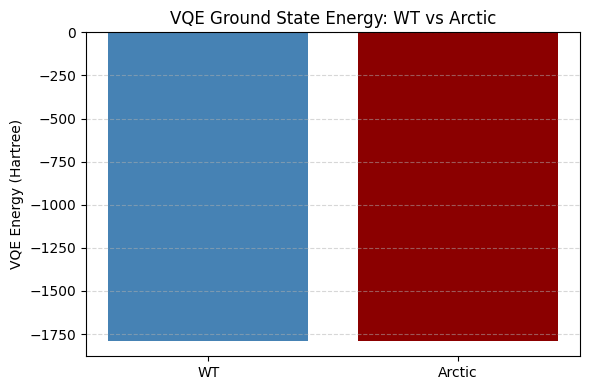

In [10]:
import matplotlib.pyplot as plt

fragments = ['WT', 'Arctic']
energies = [-1788.3671, -1789.4439]  # Hartree

plt.figure(figsize=(6, 4))
plt.bar(fragments, energies, color=['steelblue', 'darkred'])
plt.ylabel('VQE Energy (Hartree)')
plt.title('VQE Ground State Energy: WT vs Arctic')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()